In [122]:
import torch
import torchvision
from torch import nn
from torchinfo import summary
from torchvision import datasets , transforms
from torch.utils.data import DataLoader,Subset,ConcatDataset,random_split,Dataset

In [123]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

In [124]:
device

'cuda'

In [125]:
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [126]:
test_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

In [127]:
root = "./2_DeepLearing/data"

In [128]:
ds_train_raw = torchvision.datasets.Flowers102(root=root,
                                            transform=None,
                                            split="train",
                                            download=False
                                            )
ds_val_raw = torchvision.datasets.Flowers102(root=root,
                                            transform=None,
                                            split="val",
                                            download=False
                                            )
ds_test_raw = torchvision.datasets.Flowers102(root=root,
                                            transform=None,
                                            split="test",
                                            download=False
                                            )

In [129]:
full_dataset = ConcatDataset([ds_train_raw, ds_val_raw, ds_test_raw])

In [130]:
test_ratio = 0.2
test_num = int(len(full_dataset) * test_ratio)  # 1637 (tam sayı)
train_num = len(full_dataset) - test_num  # 6552 (tam sayı)

In [131]:
train_subset, test_subset = random_split(
    full_dataset,
    [train_num, test_num],
    generator=torch.Generator().manual_seed(42),  
)

In [132]:
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label

In [133]:
train_ds = TransformSubset(train_subset, train_tf)   
test_ds  = TransformSubset(test_subset,  test_tf) 

In [134]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

In [135]:
import time

start = time.time()
for i, (X, y) in enumerate(train_loader):
    if i == 20: # Sadece ilk 20 batch'e bakıyoruz
        break
print(f"20 batch yükleme süresi: {time.time() - start:.2f} saniye")

20 batch yükleme süresi: 4.93 saniye


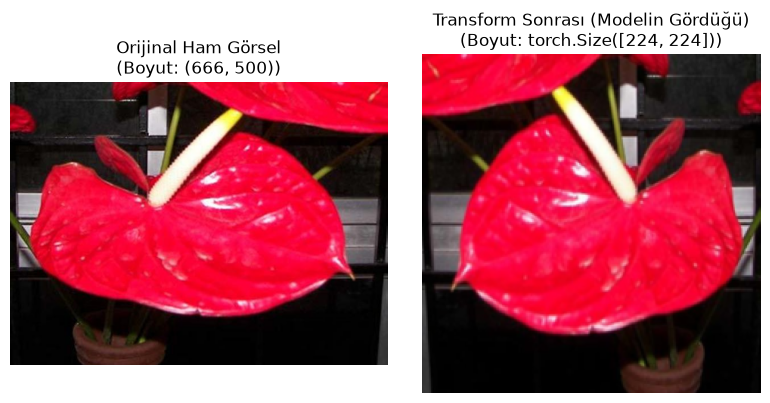

In [136]:
import random
import matplotlib.pyplot as plt
import torch

idx = random.randint(0, len(train_subset) - 1)

# 1. Ham görsel (Hiçbir transform görmemiş orijinal hali)
raw_img, label = train_subset[idx]

# 2. Transformdan geçmiş hali (Aynı indeksi train_ds'ten çekiyoruz)
tf_tensor, _ = train_ds[idx]

# Renkleri ekranda görünür kılmak için un-normalize
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
tf_img = (
    torch.clamp(tf_tensor * std + mean, 0, 1).permute(1, 2, 0).cpu().numpy()
)

# 3. Yan yana kıyaslama
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(raw_img)
axes[0].set_title(f"Orijinal Ham Görsel\n(Boyut: {raw_img.size})")
axes[0].axis("off")

axes[1].imshow(tf_img)
axes[1].set_title(
    f"Transform Sonrası (Modelin Gördüğü)\n(Boyut: {tf_tensor.shape[1:]})"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [137]:
class_names = ds_train_raw.classes

num_classes = len(ds_train_raw.classes)

print(f"Sınıf Sayısı: {num_classes}")

Sınıf Sayısı: 102


In [138]:
image,label = train_loader.dataset[10]

In [139]:
image.shape

torch.Size([3, 224, 224])

In [140]:
image = image.unsqueeze(dim = 0)
image.shape

torch.Size([1, 3, 224, 224])

In [141]:
height = 224
width = 224
color_chanels = 3
patch_size = 3
stride = 1
padding = 1
kernel_size = 3 

In [142]:
H_cod = ((height + 2 * padding - kernel_size) // stride) + 1
number_of_patches = H_cod * width
number_of_patches

50176

In [143]:
class ConvolutionalTokenization(nn.Module):
    def __init__(self, embedding_dim: int = 256):
        super().__init__()
        
        # 224x224 görseli kademeli olarak 14x14 uzamsal boyuta indirir:
        self.feature_extractor = nn.Sequential(
            # 224x224 -> 112x112
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # 112x112 -> 56x56
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            # 56x56 -> 28x28
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # 28x28 -> 14x14 ve kanal sayısını embedding_dim'e (256) eşitleme
            nn.Conv2d(in_channels=128, out_channels=embedding_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(embedding_dim),
            nn.ReLU()
        )

    def forward(self, x):
        # x: (b, 3, 224, 224)
        x = self.feature_extractor(x)          # (b, 256, 14, 14)
        x = x.flatten(2).transpose(1, 2)       # (b, 196, 256)
        return x

In [144]:
image.shape

torch.Size([1, 3, 224, 224])

In [145]:
ConvolutionalTokenization_conv_embedding = ConvolutionalTokenization()
patch_embedded_image = ConvolutionalTokenization_conv_embedding(image)

In [146]:
patch_embedded_image.shape

torch.Size([1, 196, 256])

In [147]:
class MLP_BLOCK(nn.Module):
    def __init__(self,
                 embedding_dim : int = 256,
                 drop_out : float = 0.1,
                 mlp_size : int = 512):
        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim,out_features=mlp_size),

            nn.GELU(),

            nn.Dropout(p = drop_out),

            nn.Linear(in_features=mlp_size,out_features=embedding_dim),

            nn.Dropout(p=drop_out)
        )

    def forward(self,x):
            return x + self.mlp(self.layer_norm(x))

In [148]:
class TransformerBlock(nn.Module):
    def __init__(self,
                 embedding_dim : int = 256,
                 num_head : int = 4):
        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        self.msha = nn.MultiheadAttention(embed_dim=embedding_dim,
                                          num_heads=num_head,
                                          batch_first=True)
        self.mlp = MLP_BLOCK()

    def forward(self, x):
   
        norm_x = self.layer_norm(x)
        attn_out, _ = self.msha(query=norm_x, key=norm_x, value=norm_x)
        x = x + attn_out
        x = self.mlp(x)
    
        return x

In [149]:
transformer = TransformerBlock()
transformer_image = transformer(patch_embedded_image)

In [150]:
transformer_image.shape

torch.Size([1, 196, 256])

In [151]:
class SeqPool(nn.Module):
    def __init__(self,
                 embedding_dim : int = 256):
        super().__init__()

        self.linear = nn.Linear(in_features=embedding_dim,
                                out_features=1)
        
        self.softmax = nn.Softmax(dim = -1)

    def forward(self, x):
        scores = self.linear(x)
        scores = scores.transpose(1, 2)
        weights = self.softmax(scores)
        out = torch.matmul(weights, x)
        return out.squeeze(1)

In [152]:
import torch
import torch.nn as nn

class CCT7(nn.Module):
    def __init__(self, num_classes: int = num_classes):  
        super().__init__()
        
        
        self.tokenizer = ConvolutionalTokenization(embedding_dim=256)
        
        
        self.classifier_blocks = nn.Sequential(*[
            TransformerBlock(embedding_dim=256, num_head=4) for _ in range(7)
        ])
        
        
        self.seq_pool = SeqPool(embedding_dim=256)
        
        
        self.fc = nn.Linear(in_features=256, out_features=num_classes)

    def forward(self, x):
        # x: (b, 3, 224, 224)
        x = self.tokenizer(x)           
        x = self.classifier_blocks(x)   
        x = self.seq_pool(x)            
        out = self.fc(x)                
        return out

In [153]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          device: torch.device,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    # 2. Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
               }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [154]:
cct = CCT7(num_classes=102).to(device=device)


optimizer = torch.optim.AdamW(params=cct.parameters(),
                              lr=1e-4,           
                              weight_decay=1e-2) 

loss_fn = torch.nn.CrossEntropyLoss()

In [155]:
print("Seçili Cihaz:", device)
print("Model hangi cihazda:", next(cct.parameters()).device)

Seçili Cihaz: cuda
Model hangi cihazda: cuda:0


In [156]:
print("Batch Size:", train_loader.batch_size)
print("Toplam Batch Sayısı:", len(train_loader))

Batch Size: 32
Toplam Batch Sayısı: 205


In [157]:
from torchinfo import summary


# 2. Katman katman parametre özetini al
summary(
    cct, 
    input_size=(32, 3, 224, 224), 
    col_names=["input_size", "output_size", "num_params", "trainable"],
    device=device
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
CCT7                                     [32, 3, 224, 224]         [32, 102]                 --                        True
├─ConvolutionalTokenization: 1-1         [32, 3, 224, 224]         [32, 196, 256]            --                        True
│    └─Sequential: 2-1                   [32, 3, 224, 224]         [32, 256, 14, 14]         --                        True
│    │    └─Conv2d: 3-1                  [32, 3, 224, 224]         [32, 64, 112, 112]        9,472                     True
│    │    └─BatchNorm2d: 3-2             [32, 64, 112, 112]        [32, 64, 112, 112]        128                       True
│    │    └─ReLU: 3-3                    [32, 64, 112, 112]        [32, 64, 112, 112]        --                        --
│    │    └─MaxPool2d: 3-4               [32, 64, 112, 112]        [32, 64, 56, 56]          --                        --
│    │ 

In [158]:
results = train(model=cct,
                train_dataloader=train_loader,
                test_dataloader=test_loader,
                loss_fn=loss_fn,
                optimizer=optimizer,
                device=device,
                epochs=15)

Epoch: 1 | train_loss: 3.2527 | train_acc: 0.2268 | test_loss: 2.5786 | test_acc: 0.3512
Epoch: 2 | train_loss: 2.2527 | train_acc: 0.4097 | test_loss: 2.0597 | test_acc: 0.4413
Epoch: 3 | train_loss: 1.8256 | train_acc: 0.5014 | test_loss: 1.8648 | test_acc: 0.5008
Epoch: 4 | train_loss: 1.5073 | train_acc: 0.5845 | test_loss: 1.5315 | test_acc: 0.5900
Epoch: 5 | train_loss: 1.2559 | train_acc: 0.6445 | test_loss: 1.4037 | test_acc: 0.6161
Epoch: 6 | train_loss: 1.0617 | train_acc: 0.7015 | test_loss: 1.3463 | test_acc: 0.6476
Epoch: 7 | train_loss: 0.9187 | train_acc: 0.7404 | test_loss: 1.2978 | test_acc: 0.6474
Epoch: 8 | train_loss: 0.7833 | train_acc: 0.7770 | test_loss: 1.1760 | test_acc: 0.6843
Epoch: 9 | train_loss: 0.6807 | train_acc: 0.8019 | test_loss: 1.1602 | test_acc: 0.6915
Epoch: 10 | train_loss: 0.5791 | train_acc: 0.8329 | test_loss: 1.1586 | test_acc: 0.7008
Epoch: 11 | train_loss: 0.4923 | train_acc: 0.8546 | test_loss: 1.1718 | test_acc: 0.6888
Epoch: 12 | train_l